In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [4]:
import os
print(os.getcwd())

C:\Users\anith\Projects_Portfolio\fda-drug-recall-abtesting\notebooks


In [5]:
import os

# List what's inside the data folder
files = os.listdir("../data")
print(files)

['fda_drug_recalls.xls']


In [7]:
df = pd.read_csv("../data/fda_drug_recalls.xls")

print(f"Total Records  : {df.shape[0]:,}")
print(f"Total Columns  : {df.shape[1]}")
print("-" * 35)
print(df.head(3))

Total Records  : 17,529
Total Columns  : 25
-----------------------------------
    status            city state        country classification  \
0  Ongoing      Pennington    NJ  United States       Class II   
1  Ongoing  East Brunswick    NJ  United States       Class II   
2  Ongoing         Shelton    CT  United States       Class II   

                                             openfda product_type  event_id  \
0  {'application_number': ['ANDA217656'], 'brand_...        Drugs     98560   
1  {'application_number': ['ANDA206309'], 'brand_...        Drugs     98523   
2  {'application_number': ['M003'], 'brand_name':...        Drugs     98291   

                    recalling_firm                     address_1 address_2  \
0  Zydus Pharmaceuticals (USA) Inc                 73 Route 31 N       NaN   
1      Rising Pharma Holding, Inc.  2 Tower Center Blvd Ste 1401       NaN   
2          ACME UNITED CORPORATION        1 Waterview Dr Ste 200       NaN   

  postal_code         vol

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
more_code_info,17527,99.99
address_2,15871,90.54
termination_date,2751,15.69
product_quantity,2022,11.54
postal_code,1020,5.82
state,1019,5.81
initial_firm_notification,267,1.52
voluntary_mandated,35,0.20
code_info,13,0.07
city,1,0.01


In [9]:
print("=== Classification Counts ===")
print(df['classification'].value_counts())
print("\n=== Voluntary vs Mandated ===")
print(df['voluntary_mandated'].value_counts())
print("\n=== Status Counts ===")
print(df['status'].value_counts())

=== Classification Counts ===
classification
Class II     14128
Class I       1723
Class III     1678
Name: count, dtype: int64

=== Voluntary vs Mandated ===
voluntary_mandated
Voluntary: Firm initiated    17465
FDA Mandated                    29
Name: count, dtype: int64

=== Status Counts ===
status
Terminated    14776
Ongoing        2306
Completed       447
Name: count, dtype: int64


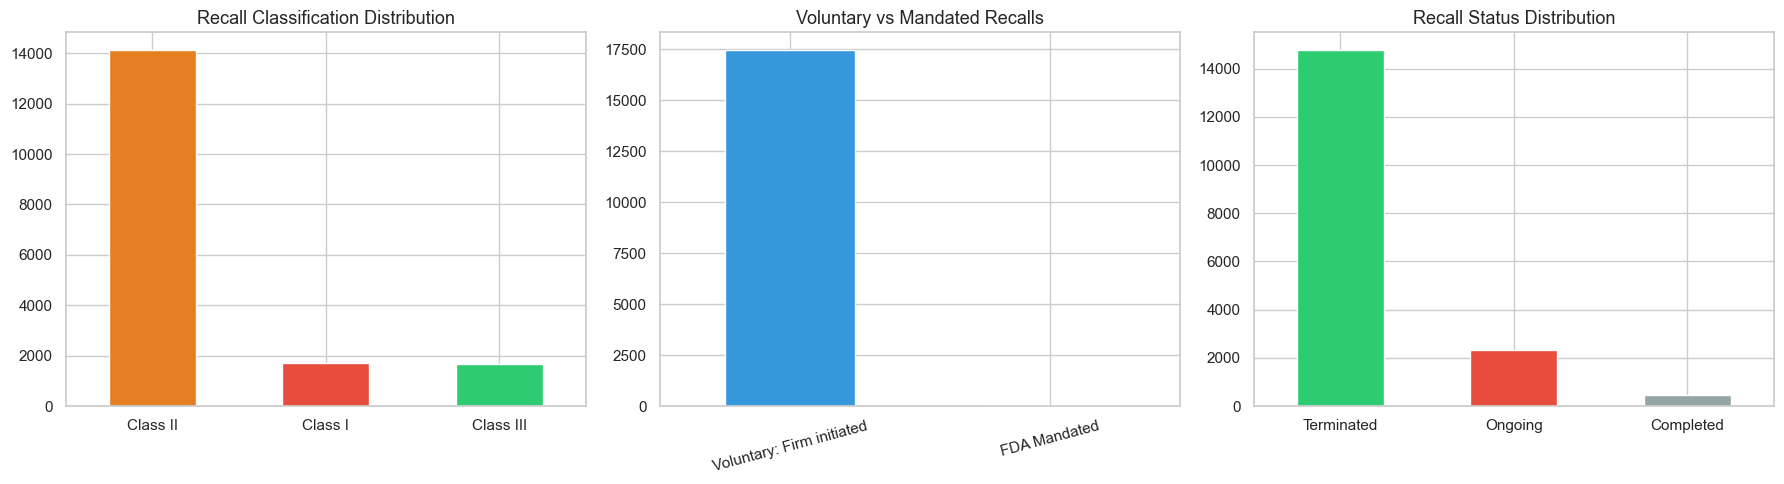

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Classification
df['classification'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#e67e22', '#e74c3c', '#2ecc71']
)
axes[0].set_title('Recall Classification Distribution', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Voluntary vs Mandated
df['voluntary_mandated'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#3498db', '#e74c3c']
)
axes[1].set_title('Voluntary vs Mandated Recalls', fontsize=13)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

# Status
df['status'].value_counts().plot(
    kind='bar', ax=axes[2],
    color=['#2ecc71', '#e74c3c', '#95a5a6']
)
axes[2].set_title('Recall Status Distribution', fontsize=13)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

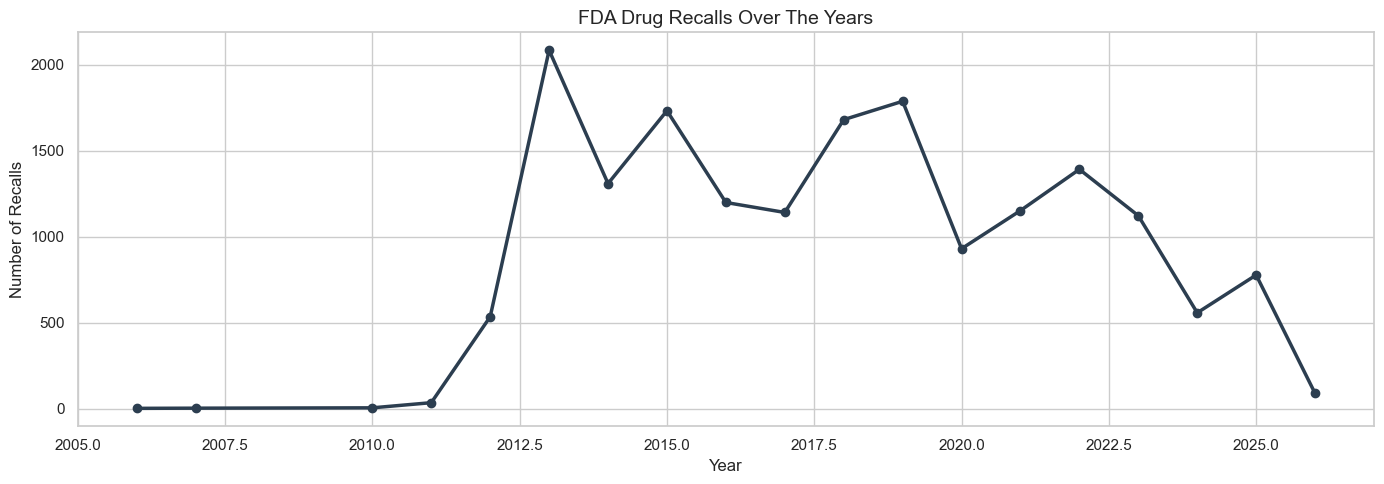

In [11]:
# Convert date column
df['recall_initiation_date'] = pd.to_datetime(
    df['recall_initiation_date'], format='%Y%m%d'
)

# Group by year
recalls_by_year = df.groupby(
    df['recall_initiation_date'].dt.year
).size()

# Plot
plt.figure(figsize=(14, 5))
recalls_by_year.plot(
    kind='line', marker='o', 
    color='#2c3e50', linewidth=2.5
)
plt.title('FDA Drug Recalls Over The Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Recalls')
plt.tight_layout()
plt.savefig('../reports/figures/02_recalls_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

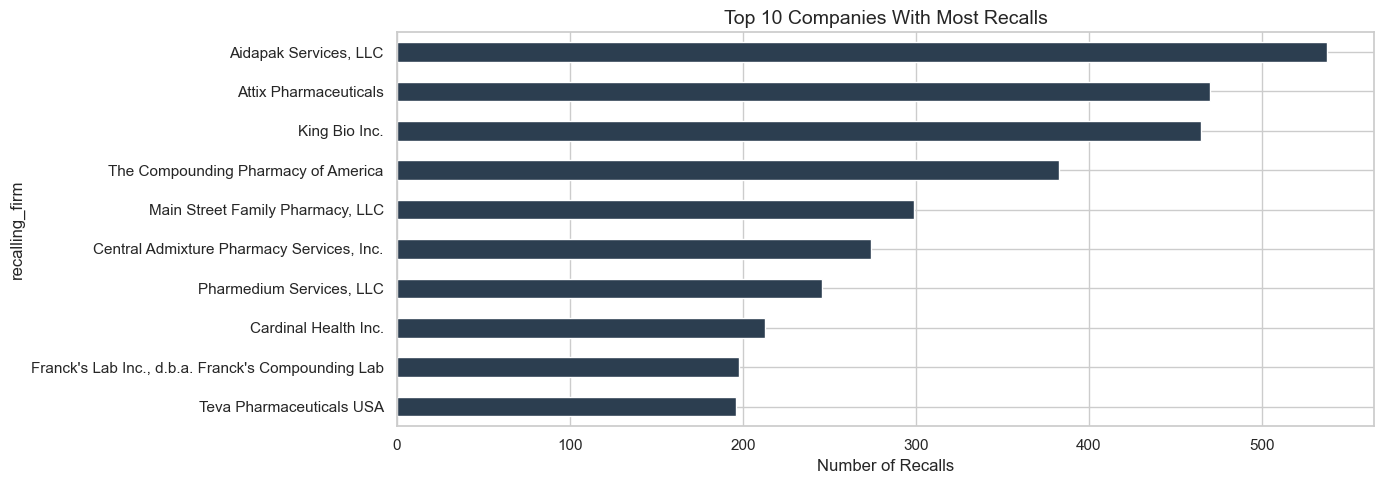

In [12]:
#Top 10 Recalling Companies
top_firms = df['recalling_firm'].value_counts().head(10)

plt.figure(figsize=(14, 5))
top_firms.plot(kind='barh', color='#2c3e50')
plt.title('Top 10 Companies With Most Recalls', fontsize=14)
plt.xlabel('Number of Recalls')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/03_top_firms.png', dpi=150, bbox_inches='tight')
plt.show()

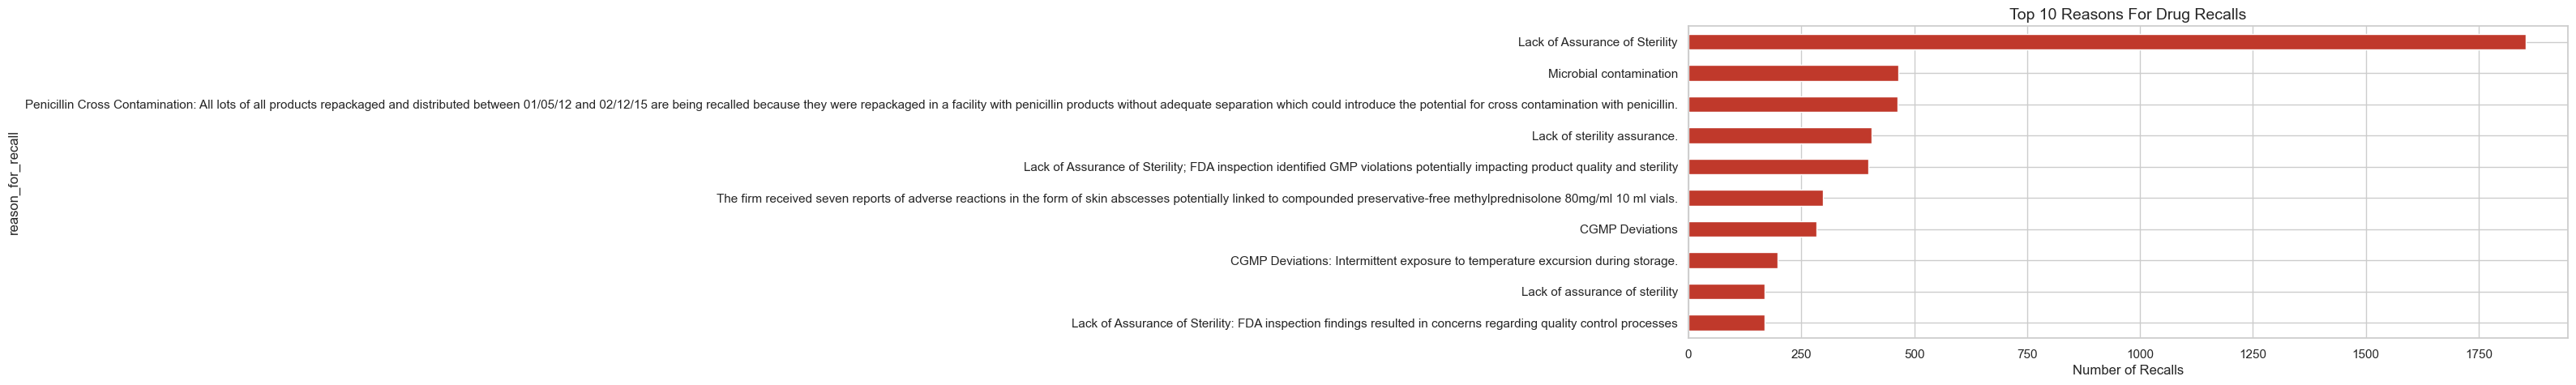

In [15]:
#Top Reasons For Recall
# Clean and get top reasons
top_reasons = df['reason_for_recall'].value_counts().head(10)

plt.figure(figsize=(14, 5))
top_reasons.plot(kind='barh', color='#c0392b')
plt.title('Top 10 Reasons For Drug Recalls', fontsize=14)
plt.xlabel('Number of Recalls')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/04_top_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

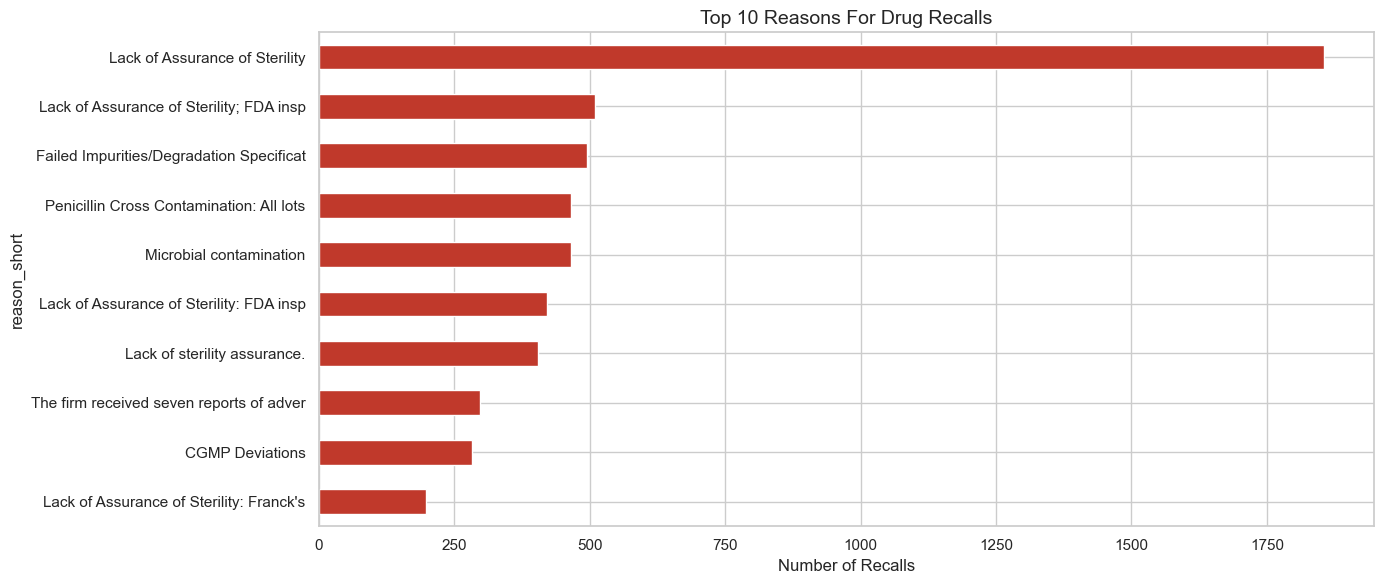

In [16]:
# Truncate long reason text to 40 characters
df['reason_short'] = df['reason_for_recall'].str[:40]

top_reasons = df['reason_short'].value_counts().head(10)

plt.figure(figsize=(14, 6))
top_reasons.plot(kind='barh', color='#c0392b')
plt.title('Top 10 Reasons For Drug Recalls', fontsize=14)
plt.xlabel('Number of Recalls')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/04_top_reasons.png', dpi=150, bbox_inches='tight')
plt.show()